###**Name :-Khushi Harishchandra Pawar
##Roll_no :- CS43
##Batch :- CS3**


####**Aim:** To implement a Simple Linear Regression model using Python and predict MPG from Horsepower using OLS.


## Task 1:Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


##**Task 2:Load Auto MPG dataset**


In [16]:
from google.colab import files

uploaded = files.upload()

Saving auto-mpg (2).csv to auto-mpg (2) (1).csv


##**Task 3 :Inspect and clean data**



In [46]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

#Cleaning of data
# Convert horsepower to numeric
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")

# Remove rows where horsepower or mpg is missing
df = df.dropna(subset=["horsepower", "mpg"])

print("Shape after cleaning:", df.shape)

print("\nMissing values after cleaning:")
print(df[["horsepower", "mpg"]].isnull().sum())

Shape of dataset: (398, 9)

Column names:
Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'],
      dtype='object')

First 5 rows:
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model year  origin                   car name  
0          70       1  chevrolet chevelle malibu  
1          70       1          buick skylark 320  
2          70       1         plymouth satellite  
3          70       1              amc rebel sst  
4          70       1                ford torino  

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIn

##**Task 4 : Select horsepower and mpg**


In [47]:
X = df["horsepower"].values
y = df["mpg"].values

print("Horsepower values:")
print(X[:10])

print("\nMPG values:")
print(y[:10])

print("Number of Horsepower values:", len(X))
print("Number of MPG values:", len(y))

selected_data = df[['horsepower', 'mpg']]

display(selected_data.head(10))


Horsepower values:
[130. 165. 150. 150. 140. 198. 220. 215. 225. 190.]

MPG values:
[18. 15. 18. 16. 17. 15. 14. 14. 14. 15.]
Number of Horsepower values: 392
Number of MPG values: 392


,horsepower,mpg
0,130.0,18.0
1,165.0,15.0
2,150.0,18.0
3,150.0,16.0
4,140.0,17.0
5,198.0,15.0
6,220.0,14.0
7,215.0,14.0
8,225.0,14.0
9,190.0,15.0


##**Task 5 : Plot scatter graph**


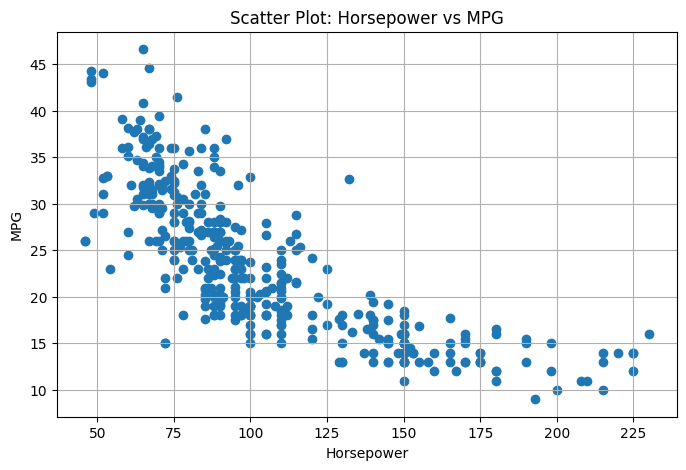

In [48]:
import matplotlib.pyplot as plt

# Plot scatter graph
plt.figure(figsize=(8, 5))

plt.scatter(X, y)

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Scatter Plot: Horsepower vs MPG")

plt.grid(True)
plt.show()

##**Task 6 : Add bias term**


In [49]:
# Add bias/intercept term
X_matrix = np.column_stack((np.ones(len(X)), X))

print("X matrix with bias term:")
print(X_matrix[:5])

X matrix with bias term:
[[  1. 130.]
 [  1. 165.]
 [  1. 150.]
 [  1. 150.]
 [  1. 140.]]


##**Task 7 : Compute correlation**


In [50]:
correlation = np.corrcoef(X, y)[0, 1]
print("Correlation between Horsepower and MPG:", correlation)

Correlation between Horsepower and MPG: -0.7784267838977756


##**Task 8 :Calculate OLS weights**


In [51]:
# Create X_bias
X_bias = np.column_stack((np.ones(len(X)), X))

# Calculate OLS weights
weights = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y

w0 = weights[0]
w1 = weights[1]

print("Intercept (w0):", w0)
print("Slope (w1):", w1)

Intercept (w0): 39.9358610211705
Slope (w1): -0.15784473335365387


##**Task 9 :Predict values**


In [52]:
y_pred = X_bias @ weights

print("Actual MPG:")
print(y[:10])

print("\nPredicted MPG:")
print(y_pred[:10])


Actual MPG:
[18. 15. 18. 16. 17. 15. 14. 14. 14. 15.]

Predicted MPG:
[19.41604569 13.89148002 16.25915102 16.25915102 17.83759835  8.68260382
  5.21001968  5.99924335  4.42079602  9.94536168]


##**Task 10 :Compute residuals**


In [53]:
residuals = y - y_pred

print("First 10 residuals:")
print(residuals[:10])

First 10 residuals:
[-1.41604569  1.10851998  1.74084898 -0.25915102 -0.83759835  6.31739618
  8.78998032  8.00075665  9.57920398  5.05463832]


##**Task 11 :Calculate SSE, MSE, R²**


In [54]:
#Calculate SSE
SSE = np.sum(residuals ** 2)
print("SSE:", SSE)

#Calculate MSE
MSE = np.mean(residuals ** 2)
print("MSE:", MSE)

#Calculate R²
SS_total = np.sum((y - np.mean(y)) ** 2)
R2 = 1 - (SSE / SS_total)
print("R²:", R2)

SSE: 9385.915871932419
MSE: 23.943662938603108
R²: 0.6059482578894348


##**Task 12 :Plot regression and residual graphs**

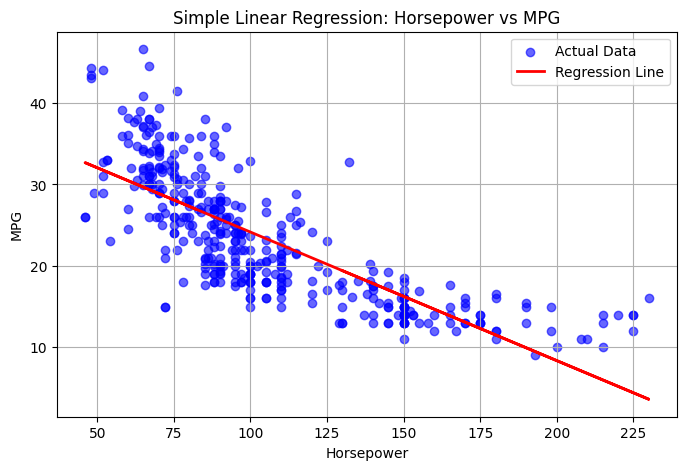

In [55]:
#Plot regression line
plt.figure(figsize=(8, 5))

plt.scatter(X, y, color="blue", alpha=0.6, label="Actual Data")

plt.plot(X, y_pred, color="red", linewidth=2, label="Regression Line")

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Simple Linear Regression: Horsepower vs MPG")

plt.legend()
plt.grid(True)
plt.show()

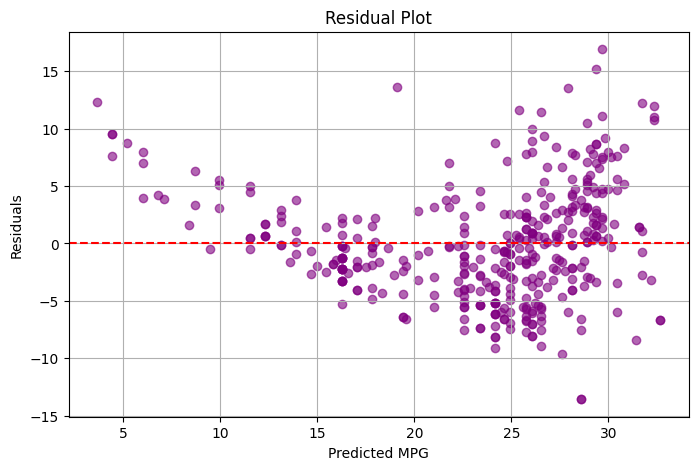

In [56]:
#Plot residual graph
plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals, color="purple", alpha=0.6)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.grid(True)
plt.show()

##**Interpretation**

The results show a **negative relationship between horsepower and MPG**. As horsepower increases, MPG generally decreases. The OLS model predicts MPG using horsepower, and the SSE, MSE, and R² values indicate the model's prediction performance. The regression and residual plots help visualize the relationship and errors.

##**Conclusion**

The experiment successfully implemented Simple Linear Regression using OLS. Horsepower showed a negative relationship with MPG, and evaluation metrics demonstrated reasonable predictive performance.